# Notebook 09 — Shift Manual de Bandas y Firmas Espectrales

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/miguepoloc/teledeteccion/blob/main/sesiones/sesion-04/colab/02_shift_manual_bandas.ipynb)

**Teledetección — Maestría en Ingeniería | Universidad del Magdalena**
**Sesión 4 | Sábado 25 Jul 2026**

Este notebook resuelve **a mano** el problema de paralaje entre las cámaras del P4M explicado en el Bloque 4: las 6 cámaras del dron no están en el mismo punto físico, así que el mismo borde de un objeto cae en píxeles ligeramente distintos según la banda. Trabajamos sobre **una sola captura real** del vuelo —no sobre el vuelo completo— con las 5 bandas multiespectrales de esa captura: Blue, Green, Red, Red Edge y NIR.

### Lo que haremos
1. Cargar las bandas de una captura real del P4M con `rasterio`
2. Encontrar varios bordes reales con contraste fuerte y elegir el más confiable para corregir
3. Calcular NDVI **sin corregir** sobre ese borde — ver el artefacto
4. Probar valores de shift (dx, dy) a simple vista y confirmar con una búsqueda sistemática
5. Recalcular el NDVI corregido y comparar antes/después
6. Extraer firmas espectrales de varias coberturas y compararlas con las de referencia de la Sesión 1

### Dato de la captura usada en este notebook
Captura real del P4M: grupo `DJI_0040` (vuelo de práctica, archivos originales en
`datos/vuelos/01 - Geraldin/`). El P4M numera cada disparo con un JPG "display"
(`DJI_0040.JPG`) seguido de sus 5 TIFs individuales (`DJI_0041.TIF` … `DJI_0045.TIF`) en el
orden fijo de fábrica Blue → Green → Red → Red Edge → NIR — confirmado leyendo el tag XMP
(`BandName`, `CentralWavelength`) embebido en cada TIF, no asumido.

**Nota sobre el terreno de esta captura:** la escena tiene plantas de altura considerable (relieve real), no un terreno perfectamente plano. Vas a ver en la Parte 2 que esto significa exactamente lo que advirtió el docente en el Bloque 4: *"el shift manual es una aproximación que asume terreno relativamente plano... en terreno con relieve importante, el corrimiento real varía según la elevación de cada punto"*. Por eso elegimos, de varios candidatos, el punto donde el shift funciona de forma más confiable.

---

## Parte 0 — Instalación

In [1]:
# En entorno local (Conda `teledeteccion`): rasterio ya debe estar instalado
# En Colab:
try:
    import rasterio
    print(f'rasterio {rasterio.__version__} — OK')
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'rasterio', '--quiet'])
    import rasterio

import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
print('Librerías listas')

rasterio 1.5.0 — OK


Librerías listas


## Parte 1 — Cargar las bandas de una captura real del P4M

A diferencia de los Notebooks 07 y 08, aquí **no generamos una imagen sintética de respaldo** — el ejercicio de shift manual necesita el desalineamiento físico real entre cámaras, y una imagen sintética generada banda por banda con la misma máscara de coberturas no tiene ese desalineamiento.

Este notebook busca los archivos de la captura en dos lugares posibles, en este orden:
1. **Ruta local del repo** (`RUTA_BASE` abajo) — funciona si clonaste el repositorio completo y la carpeta `datos/` está sincronizada (vía OneDrive o similar) junto a él. Este es el caso normal si ejecutas el notebook con el entorno Conda `teledeteccion` de la sesión anterior.
2. **Carpeta actual de Colab** — si subiste los 5 archivos sueltos directamente a la sesión de Colab.

Si ninguna existe, el notebook te dice exactamente qué archivos subir manualmente.

In [2]:
# Nombre exacto de la captura usada en este notebook (vuelo real, carpeta de vuelos de estudiantes)
# El P4M numera cada disparo con un JPG "display" (ej. DJI_0040.JPG) seguido de sus 5 TIFs
# individuales (DJI_0041..DJI_0045.TIF): el offset 1..5 respecto al número de captura sigue
# siempre el mismo orden de fábrica Blue, Green, Red, Red Edge, NIR (confirmado leyendo el tag
# XMP BandName/CentralWavelength de cada TIF, no asumido).
CAPTURA = 'DJI_0040'
SUFIJO_BANDA = {'B': 1, 'G': 2, 'R': 3, 'RE': 4, 'NIR': 5}

# Si clonaste el repo completo con la carpeta datos/ sincronizada, esta ruta relativa
# encuentra los archivos automáticamente (ejecutando el notebook desde colab/ dentro del repo).
RUTA_BASE = '../../../datos/vuelos/01 - Geraldin'

def rutas_para(base):
    numero_grupo = int(CAPTURA.split('_')[1])
    return {b: f'{base}/DJI_{numero_grupo + offset:04d}.TIF' for b, offset in SUFIJO_BANDA.items()}

rutas = rutas_para(RUTA_BASE)

if not all(os.path.exists(r) for r in rutas.values()):
    # Intento 2: archivos sueltos en la carpeta actual (típico si los subiste a Colab)
    rutas_local = rutas_para('.')
    if all(os.path.exists(r) for r in rutas_local.values()):
        rutas = rutas_local

archivos_ok = all(os.path.exists(r) for r in rutas.values())

if not archivos_ok:
    print('⚠ No se encontraron los 5 archivos de la captura ni en la ruta local del repo ni en la carpeta actual.')
    print()
    print('Archivos que necesitas subir (pídeselos al docente si no los tienes):')
    for r in rutas_para('.').values():
        print(f'  {os.path.basename(r)}')
    print()
    print('En Google Colab, descomenta y ejecuta esta línea para subirlos desde tu computador:')
    print("  # from google.colab import files; uploaded = files.upload()")
    print()
    print('Después de subir los 5 archivos a la carpeta raíz de Colab, vuelve a ejecutar esta celda.')
else:
    print('Archivos encontrados:')
    for b, r in rutas.items():
        print(f'  {b}: {r}')

Archivos encontrados:
  B: ../../../datos/vuelos/01 - Geraldin/DJI_0041.TIF
  G: ../../../datos/vuelos/01 - Geraldin/DJI_0042.TIF
  R: ../../../datos/vuelos/01 - Geraldin/DJI_0043.TIF
  RE: ../../../datos/vuelos/01 - Geraldin/DJI_0044.TIF
  NIR: ../../../datos/vuelos/01 - Geraldin/DJI_0045.TIF


In [3]:
bandas = {}
perfil = None

for b, r in rutas.items():
    with rasterio.open(r) as src:
        bandas[b] = src.read(1).astype(np.float32)
        if perfil is None:
            perfil = src.profile.copy()

blue, green, red, re, nir = bandas['B'], bandas['G'], bandas['R'], bandas['RE'], bandas['NIR']

print('=== Metadatos de la captura ===')
print(f'Captura:      {CAPTURA}')
print(f'Dimensiones:  {green.shape[1]} × {green.shape[0]} px')
print(f'Dtype:        {perfil["dtype"] if perfil else "?"}')
print('Bandas cargadas: Blue (450 nm), Green (560 nm), Red (650 nm), Red Edge (730 nm), NIR (840 nm)')

=== Metadatos de la captura ===
Captura:      DJI_0040
Dimensiones:  1600 × 1300 px
Dtype:        uint16
Bandas cargadas: Blue (450 nm), Green (560 nm), Red (650 nm), Red Edge (730 nm), NIR (840 nm)


## Parte 2 — Encontrar un borde confiable para corregir

A escala completa (miles de píxeles), un corrimiento de unos pocos píxeles entre bandas es invisible. Para verlo necesitamos una ventana de zoom sobre un borde de alto contraste. Pero en terreno con relieve (como esta captura, con plantas de altura considerable), **el corrimiento real no es el mismo en todos los bordes** — varía según qué tan alto esté el objeto sobre el suelo (Bloque 4).

Por eso, en vez de tomar el primer borde que encontremos, probamos varios candidatos y nos quedamos con el más *confiable*: aquel donde un solo valor de (dx, dy) alinea mejor las bandas, medido con correlación cruzada normalizada (NCC — un número entre -1 y 1; más cerca de 1 = mejor alineación posible con un shift constante).

In [4]:
def gradiente_magnitud(banda):
    gy, gx = np.gradient(banda)
    return np.abs(gx) + np.abs(gy)

def candidatos_de_borde(banda, n=6, margen=150, separacion=80):
    """Devuelve hasta n puntos (fila, col) de alto contraste, evitando el marco
    exterior de la imagen y sin que queden demasiado cerca entre sí."""
    g = gradiente_magnitud(banda).copy()
    g[:margen, :] = 0; g[-margen:, :] = 0
    g[:, :margen] = 0; g[:, -margen:] = 0
    orden = np.argsort(g.ravel())[::-1]
    puntos = []
    for idx in orden:
        fila, col = np.unravel_index(idx, g.shape)
        if all(abs(fila - f) > separacion or abs(col - c) > separacion for f, c in puntos):
            puntos.append((int(fila), int(col)))
        if len(puntos) >= n:
            break
    return puntos

VENTANA = 60  # medio-lado del recorte de zoom, en píxeles
RANGO_BUSQUEDA = range(-30, 31)  # píxeles de shift a probar en cada dirección
# (esta captura es de vuelo bajo/cercano al suelo: el paralaje en píxeles es mayor que en
# capturas de vuelo alto, por eso el rango es más amplio que en otros notebooks del curso)

def recortar(banda, fila, col, ventana=VENTANA):
    return banda[fila - ventana:fila + ventana, col - ventana:col + ventana]

def normalizar(banda, percentil=2):
    p_low  = np.percentile(banda, percentil)
    p_high = np.percentile(banda, 100 - percentil)
    return np.clip((banda - p_low) / (p_high - p_low + 1e-6), 0, 1)

def aplicar_shift(banda, dx, dy):
    """Desplaza una banda dx columnas y dy filas (shift circular con np.roll)."""
    return np.roll(banda, shift=(dy, dx), axis=(0, 1))

def ncc(a, b):
    """Correlación cruzada normalizada entre dos recortes del mismo tamaño."""
    a = a - a.mean(); b = b - b.mean()
    denom = np.sqrt((a**2).sum()) * np.sqrt((b**2).sum())
    return float((a * b).sum() / denom) if denom > 0 else -1.0

def mejor_shift_local(banda_ref, banda_mover, fila, col):
    """Busca, sobre RANGO_BUSQUEDA, el (dx,dy) que maximiza la NCC en ese punto."""
    ref_crop = recortar(banda_ref, fila, col)
    mejor = (-2.0, (0, 0))
    for dy in RANGO_BUSQUEDA:
        for dx in RANGO_BUSQUEDA:
            crop_mov = recortar(aplicar_shift(banda_mover, dx, dy), fila, col)
            score = ncc(ref_crop, crop_mov)
            if score > mejor[0]:
                mejor = (score, (dx, dy))
    return mejor

In [5]:
candidatos = candidatos_de_borde(red)

print(f'{"Punto (fila,col)":<20} {"NCC":>6} {"dx":>4} {"dy":>4}')
print('-' * 40)
resultados = []
for (fila, col) in candidatos:
    score, (dx, dy) = mejor_shift_local(red, nir, fila, col)
    resultados.append((fila, col, score, dx, dy))
    print(f'({fila:>4}, {col:>4}){"":<7} {score:>6.3f} {dx:>4} {dy:>4}')

# Elegimos el punto con MAYOR NCC: es donde un solo (dx, dy) alinea mejor las bandas
fila_borde, col_borde, mejor_ncc, DX, DY = max(resultados, key=lambda t: t[2])
print()
print(f'Punto elegido: fila={fila_borde}, col={col_borde}  (NCC={mejor_ncc:.3f}, dx={DX}, dy={DY})')
print()
print('Si algún punto de la tabla tiene una NCC mucho más baja que los demás, probablemente cae')
print('sobre una planta alta (más relieve) — ahí el mismo (dx, dy) no corrige tan bien. Esa es')
print('justamente la limitación del shift manual que se explicó en el Bloque 4.')

Punto (fila,col)        NCC   dx   dy
----------------------------------------


( 403, 1042)         0.896  -29   21


(1148,  762)         0.913  -22   17


( 950, 1036)         0.264  -23   18


( 939,  662)         0.995  -22   18


( 821,  690)         0.952  -22   19


( 622,  497)         0.448  -21   20

Punto elegido: fila=939, col=662  (NCC=0.995, dx=-22, dy=18)

Si algún punto de la tabla tiene una NCC mucho más baja que los demás, probablemente cae
sobre una planta alta (más relieve) — ahí el mismo (dx, dy) no corrige tan bien. Esa es
justamente la limitación del shift manual que se explicó en el Bloque 4.


## Parte 3 — Visualizar el corrimiento en el punto elegido

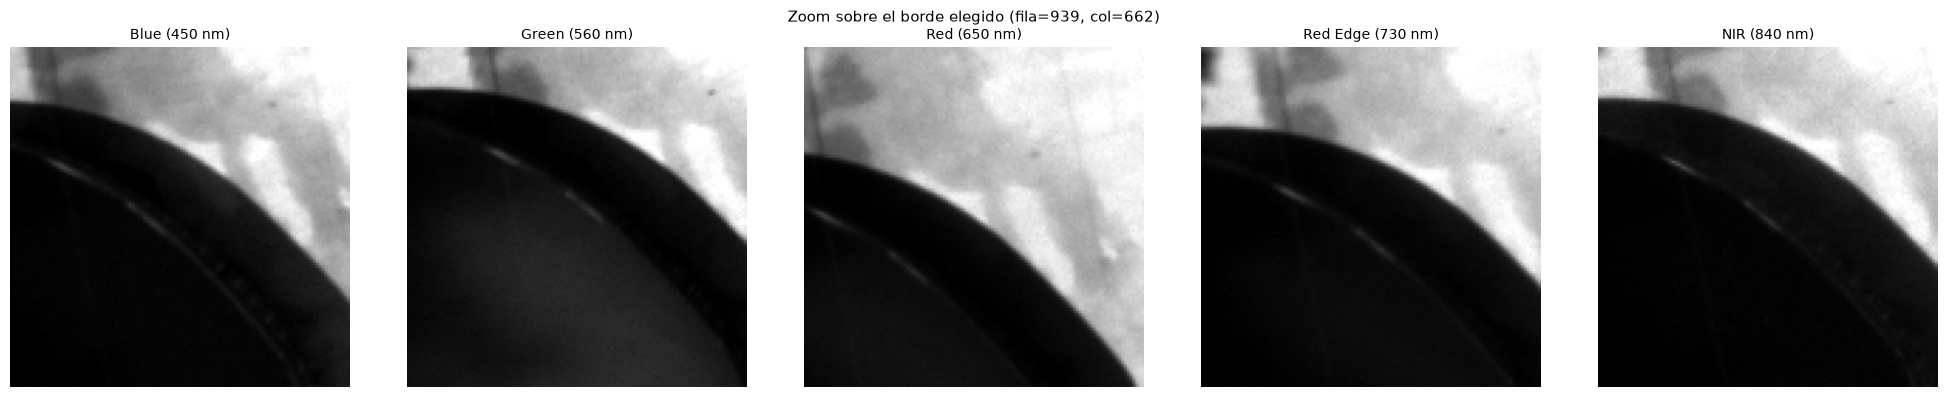

In [6]:
# Las 5 bandas, recortadas alrededor del borde elegido — a simple vista se ven "iguales"
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, banda, nombre in zip(axes, [blue, green, red, re, nir],
                              ['Blue (450 nm)', 'Green (560 nm)', 'Red (650 nm)', 'Red Edge (730 nm)', 'NIR (840 nm)']):
    ax.imshow(normalizar(recortar(banda, fila_borde, col_borde)), cmap='gray')
    ax.set_title(nombre, fontsize=10)
    ax.axis('off')
fig.suptitle(f'Zoom sobre el borde elegido (fila={fila_borde}, col={col_borde})', fontsize=11)
plt.tight_layout()
plt.show()

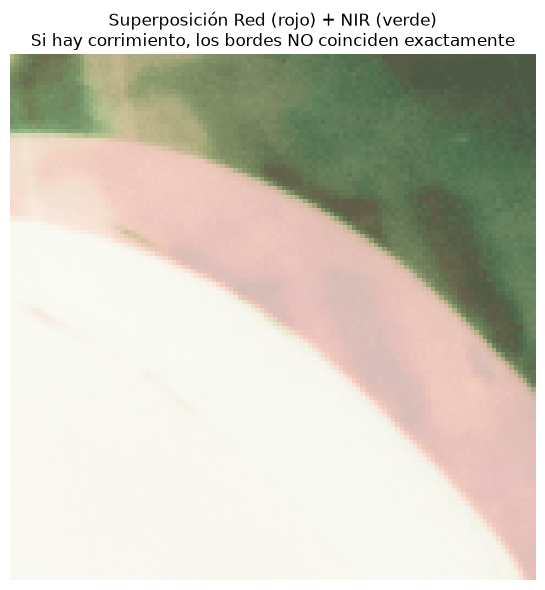

In [7]:
# Superponer Red y NIR con transparencia — aquí sí se nota el corrimiento
crop_red_norm = normalizar(recortar(red, fila_borde, col_borde))
crop_nir_norm = normalizar(recortar(nir, fila_borde, col_borde))

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(crop_red_norm, cmap='Reds', alpha=0.55)
ax.imshow(crop_nir_norm, cmap='Greens', alpha=0.55)
ax.set_title('Superposición Red (rojo) + NIR (verde)\nSi hay corrimiento, los bordes NO coinciden exactamente')
ax.axis('off')
plt.tight_layout()
plt.show()

## Parte 4 — Calcular NDVI sin corregir sobre el borde — el artefacto

Ahora calculamos el NDVI exactamente sobre este recorte, sin aplicar ningún shift (dx=0, dy=0). Si hay corrimiento entre Red y NIR, vamos a ver una franja de valores absurdos justo en la línea del borde — el mismo artefacto que se explicó en el Bloque 4.

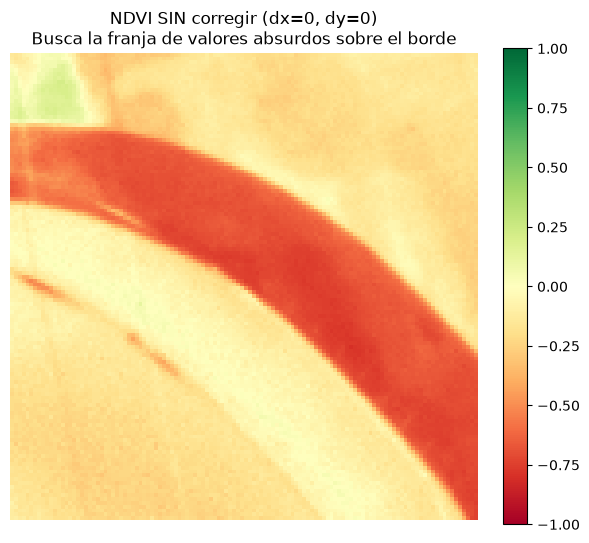

Rango de NDVI sin corregir: [-0.80, 0.21]
Píxeles con valores extremos (artefacto): 3565


In [8]:
eps = 1e-6  # evitar división por cero

def ndvi_de(banda_red, banda_nir):
    return (banda_nir - banda_red) / (banda_nir + banda_red + eps)

red_crop_fijo = recortar(red, fila_borde, col_borde)
ndvi_sin_corregir = ndvi_de(red_crop_fijo, recortar(nir, fila_borde, col_borde))

fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(ndvi_sin_corregir, cmap='RdYlGn', vmin=-1, vmax=1)
ax.set_title('NDVI SIN corregir (dx=0, dy=0)\nBusca la franja de valores absurdos sobre el borde')
ax.axis('off')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

def pixeles_extremos(ndvi_arr):
    """Cuenta píxeles con NDVI fuera de un rango realista de vegetación/suelo — señal de artefacto."""
    return int(np.sum((ndvi_arr < -0.5) | (ndvi_arr > 0.95)))

print(f'Rango de NDVI sin corregir: [{ndvi_sin_corregir.min():.2f}, {ndvi_sin_corregir.max():.2f}]')
print(f'Píxeles con valores extremos (artefacto): {pixeles_extremos(ndvi_sin_corregir)}')

## Parte 5 — Aplicar el shift manual (dx, dy)

Como explicó el docente: *"El número exacto de dx, dy que les va a funcionar mejor lo van a tener que probar — no hay un valor universal, depende de la altura real de vuelo de hoy. Prueben 2-3 valores y quédense con el que mejor alinea los bordes a simple vista."*

### Paso 5a — Prueba manual: comparar el shift elegido contra vecinos cercanos, a simple vista

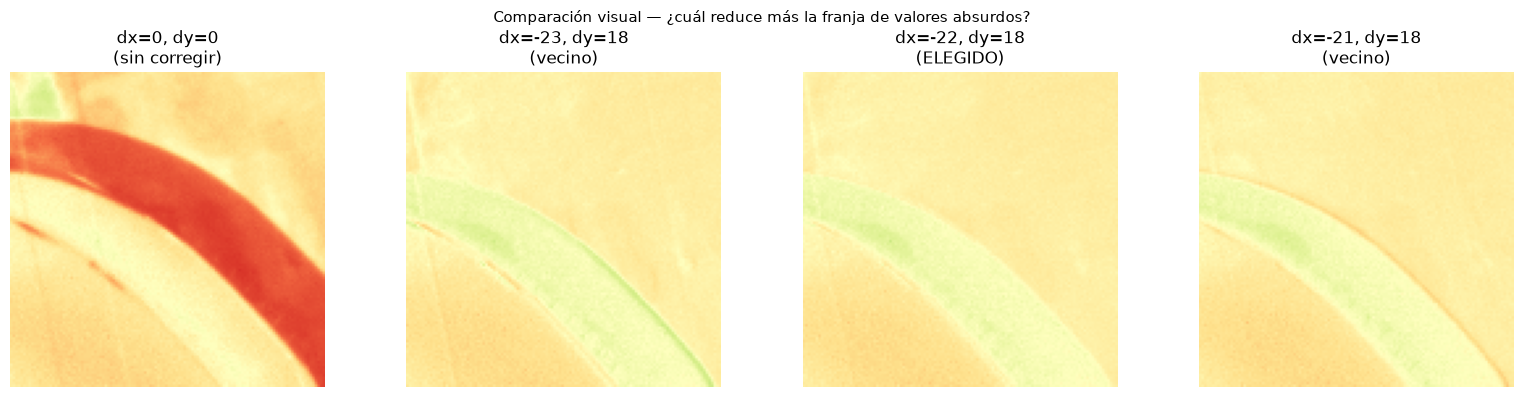

In [9]:
# Comparamos el (DX, DY) encontrado en la Parte 2 contra un par de valores vecinos,
# exactamente como lo haría un grupo probando "a ojo" en clase
candidatos_visuales = [(0, 0), (DX - 1, DY), (DX, DY), (DX + 1, DY)]

fig, axes = plt.subplots(1, len(candidatos_visuales), figsize=(4 * len(candidatos_visuales), 4))
for ax, (dx, dy) in zip(axes, candidatos_visuales):
    nir_prueba = recortar(aplicar_shift(nir, dx, dy), fila_borde, col_borde)
    ndvi_prueba = ndvi_de(red_crop_fijo, nir_prueba)
    ax.imshow(ndvi_prueba, cmap='RdYlGn', vmin=-1, vmax=1)
    etiqueta = 'sin corregir' if (dx, dy) == (0, 0) else ('ELEGIDO' if (dx, dy) == (DX, DY) else 'vecino')
    ax.set_title(f'dx={dx}, dy={dy}\n({etiqueta})')
    ax.axis('off')

plt.suptitle('Comparación visual — ¿cuál reduce más la franja de valores absurdos?', fontsize=11)
plt.tight_layout()
plt.show()

### Paso 5b — Confirmación: el shift elegido ya viene de una búsqueda sistemática

En la Parte 2 no adivinamos (DX, DY) — lo calculamos maximizando la correlación cruzada (NCC) entre Red y NIR en el punto elegido. Esta celda solo confirma numéricamente esa elección, igual que WebODM hace un cálculo equivalente (pero mucho más completo, en 3D y para el vuelo entero) en el Bloque 4.

In [10]:
print(f'(DX, DY) elegido en la Parte 2: ({DX}, {DY})  con NCC = {mejor_ncc:.3f}')
print()
print('Este valor NO es universal — depende de la altura real de vuelo de ESTE vuelo específico,')
print('y —como viste en la tabla de la Parte 2— también puede variar según el relieve del punto elegido.')
print('En clase, cada grupo repite este mismo procedimiento (o la prueba manual del Paso 5a) sobre SU propia captura.')

(DX, DY) elegido en la Parte 2: (-22, 18)  con NCC = 0.995

Este valor NO es universal — depende de la altura real de vuelo de ESTE vuelo específico,
y —como viste en la tabla de la Parte 2— también puede variar según el relieve del punto elegido.
En clase, cada grupo repite este mismo procedimiento (o la prueba manual del Paso 5a) sobre SU propia captura.


## Parte 6 — Recalcular el NDVI corregido y comparar antes/después

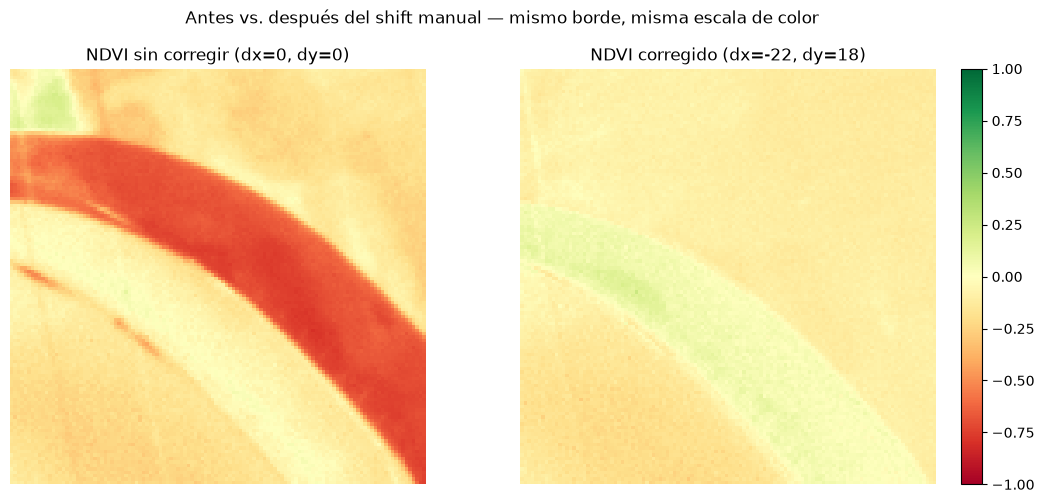

Rango NDVI sin corregir: [-0.80, 0.21]  (3565 píxeles extremos)
Rango NDVI corregido:    [-0.28, 0.26]  (0 píxeles extremos)
Reducción de píxeles con artefacto: 100%


In [11]:
nir_corregido_crop = recortar(aplicar_shift(nir, DX, DY), fila_borde, col_borde)
ndvi_corregido = ndvi_de(red_crop_fijo, nir_corregido_crop)

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
im0 = axes[0].imshow(ndvi_sin_corregir, cmap='RdYlGn', vmin=-1, vmax=1)
axes[0].set_title('NDVI sin corregir (dx=0, dy=0)')
axes[0].axis('off')

im1 = axes[1].imshow(ndvi_corregido, cmap='RdYlGn', vmin=-1, vmax=1)
axes[1].set_title(f'NDVI corregido (dx={DX}, dy={DY})')
axes[1].axis('off')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

plt.suptitle('Antes vs. después del shift manual — mismo borde, misma escala de color', fontsize=12)
plt.tight_layout()
plt.show()

extremos_antes = pixeles_extremos(ndvi_sin_corregir)
extremos_despues = pixeles_extremos(ndvi_corregido)
print(f'Rango NDVI sin corregir: [{ndvi_sin_corregir.min():.2f}, {ndvi_sin_corregir.max():.2f}]  ({extremos_antes} píxeles extremos)')
print(f'Rango NDVI corregido:    [{ndvi_corregido.min():.2f}, {ndvi_corregido.max():.2f}]  ({extremos_despues} píxeles extremos)')
reduccion = 100 * (1 - extremos_despues / extremos_antes) if extremos_antes else 0
print(f'Reducción de píxeles con artefacto: {reduccion:.0f}%')

In [12]:
def aplicar_shift_y_recortar(banda_ref, banda_mover, dx, dy):
    """Para usar sobre la imagen COMPLETA (no solo el recorte de zoom): aplica el shift a
    banda_mover, y recorta AMBAS bandas a la misma ventana válida (Bloque 4 y Bloque 7, Paso 2) —
    el borde que queda sin dato real tras el desplazamiento se descarta en las dos bandas por igual,
    para que sigan alineadas espacialmente entre sí."""
    filas, cols = banda_ref.shape
    r0 = max(dy, 0); r1 = filas + min(dy, 0)
    c0 = max(dx, 0); c1 = cols + min(dx, 0)
    mov_desplazada = aplicar_shift(banda_mover, dx, dy)
    return banda_ref[r0:r1, c0:c1], mov_desplazada[r0:r1, c0:c1]

red_full_recortado, nir_full_corregido = aplicar_shift_y_recortar(red, nir, DX, DY)

print(f'Dimensiones originales:        {red.shape}')
print(f'Dimensiones tras shift+recorte: {red_full_recortado.shape}  (misma forma en ambas bandas, ya alineadas)')
print('Esto es lo que se exportaría como composite corregido — el mismo concepto del Bloque 7, Paso 2.')

Dimensiones originales:        (1300, 1600)
Dimensiones tras shift+recorte: (1282, 1578)  (misma forma en ambas bandas, ya alineadas)
Esto es lo que se exportaría como composite corregido — el mismo concepto del Bloque 7, Paso 2.


### Exportar el composite corregido (para georreferenciar en el Bloque 9)

El resultado de esta sección —las 5 bandas ya alineadas entre sí, recortadas al área válida— es exactamente el "composite armado a mano" del que habla el Bloque 3: sus píxeles ya coinciden entre bandas, pero el archivo **todavía no tiene ningún sistema de coordenadas asignado ni está orientado al norte**. Ese es el problema que se resuelve a continuación en el Bloque 9, georreferenciando este mismo archivo en QGIS (`qgis/guia_georreferenciacion_y_layout.md`).

In [13]:
# Recortamos Blue, Green y Red Edge a la misma ventana válida que Red/NIR (Parte 6),
# para que las 5 bandas queden con exactamente el mismo tamaño y sigan alineadas entre sí.
filas, cols = red.shape
r0 = max(DY, 0); r1 = filas + min(DY, 0)
c0 = max(DX, 0); c1 = cols + min(DX, 0)

blue_export = blue[r0:r1, c0:c1]
green_export = green[r0:r1, c0:c1]
re_export = re[r0:r1, c0:c1]
# red_full_recortado y nir_full_corregido ya vienen de la Parte 6 con este mismo recorte

RUTA_COMPOSITE = 'composite_shift_corregido.tif'

perfil_export = perfil.copy()
perfil_export.update({
    'height': red_full_recortado.shape[0],
    'width': red_full_recortado.shape[1],
    'count': 5,
    'dtype': 'float32',
})
# Nota: no asignamos CRS ni transform reales -- ese es exactamente el problema que
# resuelve la georreferenciación manual en QGIS (Bloque 3 y Bloque 9), no este notebook.
perfil_export.pop('crs', None)
perfil_export.pop('transform', None)

with rasterio.open(RUTA_COMPOSITE, 'w', **perfil_export) as dst:
    dst.write(blue_export.astype('float32'), 1)
    dst.write(green_export.astype('float32'), 2)
    dst.write(red_full_recortado.astype('float32'), 3)
    dst.write(re_export.astype('float32'), 4)
    dst.write(nir_full_corregido.astype('float32'), 5)
    dst.update_tags(1, banda_nombre='Blue')
    dst.update_tags(2, banda_nombre='Green')
    dst.update_tags(3, banda_nombre='Red')
    dst.update_tags(4, banda_nombre='RedEdge')
    dst.update_tags(5, banda_nombre='NIR_corregida')

print(f'Composite exportado: {RUTA_COMPOSITE}')
print(f'Bandas (en orden): Blue, Green, Red, RedEdge, NIR_corregida')
print(f'Dimensiones: {red_full_recortado.shape[1]} × {red_full_recortado.shape[0]} px')
print('Sin CRS ni transform reales todavía -- eso se resuelve en el Bloque 9 (QGIS Georeferencer).')

Composite exportado: composite_shift_corregido.tif
Bandas (en orden): Blue, Green, Red, RedEdge, NIR_corregida
Dimensiones: 1578 × 1282 px
Sin CRS ni transform reales todavía -- eso se resuelve en el Bloque 9 (QGIS Georeferencer).


## Parte 7 — Firmas espectrales

Sobre la imagen ya corregida (Bloque 7, Paso 3): identificamos varias coberturas visibles en la captura y comparamos su perfil de reflectancia a lo largo de las 5 bandas disponibles.

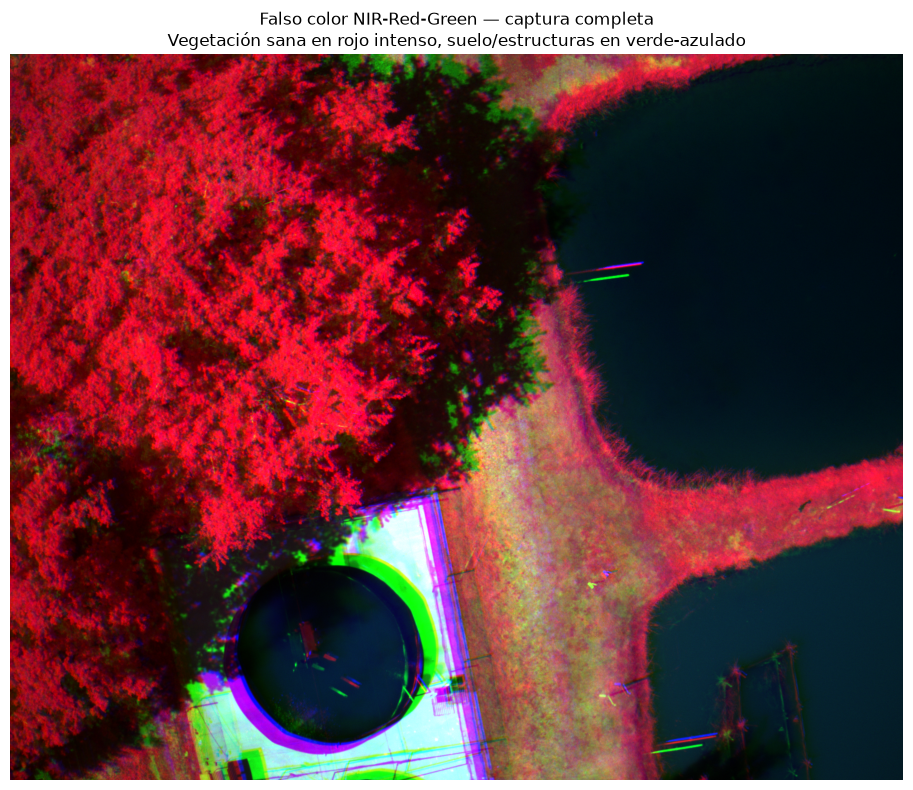

In [14]:
# Composición falso color (NIR-Red-Green) sobre la imagen completa, para identificar coberturas
def normalizar_full(banda, p=2):
    lo, hi = np.percentile(banda, p), np.percentile(banda, 100 - p)
    return np.clip((banda - lo) / (hi - lo + 1e-6), 0, 1)

cir = np.dstack([normalizar_full(nir), normalizar_full(red), normalizar_full(green)])

fig, ax = plt.subplots(figsize=(11, 8))
ax.imshow(cir)
ax.set_title('Falso color NIR-Red-Green — captura completa\nVegetación sana en rojo intenso, suelo/estructuras en verde-azulado')
ax.axis('off')
plt.tight_layout()
plt.show()

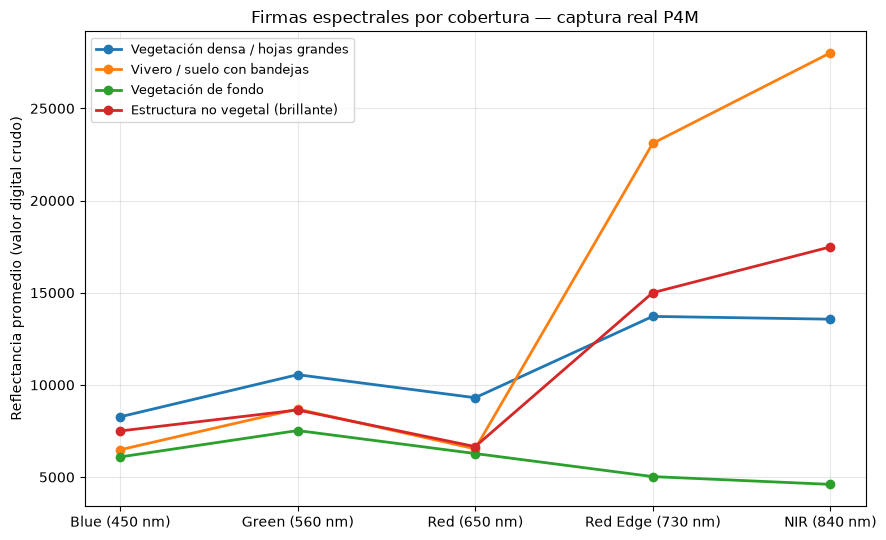

In [15]:
# Regiones de ejemplo (fila_ini, fila_fin, col_ini, col_fin) -- AJUSTA estas coordenadas
# mirando la composición falso color de la celda anterior. Estas son un punto de partida,
# no coordenadas validadas para tu propia captura o sesión.
REGIONES = {
    'Vegetación densa / hojas grandes': (300, 900,  900, 1600),
    'Vivero / suelo con bandejas':      (364, 546,  104, 364),
    'Vegetación de fondo':              (100, 300, 1400, 2200),
    'Estructura no vegetal (brillante)': (624, 806,  598, 806),
}

BANDAS_ORDEN = ['Blue (450 nm)', 'Green (560 nm)', 'Red (650 nm)', 'Red Edge (730 nm)', 'NIR (840 nm)']
stack_bandas = [blue, green, red, re, nir]

perfiles = {}
for nombre, (r0, r1, c0, c1) in REGIONES.items():
    perfiles[nombre] = [banda[r0:r1, c0:c1].mean() for banda in stack_bandas]

fig, ax = plt.subplots(figsize=(9, 5.5))
for nombre, valores in perfiles.items():
    ax.plot(BANDAS_ORDEN, valores, marker='o', linewidth=2, label=nombre)
ax.set_ylabel('Reflectancia promedio (valor digital crudo)')
ax.set_title('Firmas espectrales por cobertura — captura real P4M')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Comparar contra las firmas de referencia de la Sesión 1

Recuerda las tres firmas de referencia (`sesion-01/teoria/04 - Firmas espectrales.pdf`):
- **Vegetación sana:** salto fuerte de Red a NIR (Red bajo, NIR alto)
- **Agua:** reflectancia baja y plana en todas las bandas
- **Suelo desnudo:** curva más uniforme, sin salto marcado entre bandas

Revisa el gráfico anterior: la curva de *'Vegetación densa / hojas grandes'* debería mostrar el salto Red→NIR más marcado de las cuatro. Las curvas de zonas con menos vegetación (vivero, estructuras) deberían verse más planas o incluso decrecientes hacia el NIR, sin el salto ascendente característico de la vegetación sana — como es esperado para suelo o superficies reflectantes no vegetales.

*"Esto es lo mismo que hicimos con NDVI, pero ahora viendo las bandas completas en vez de resumir todo en un solo número — el perfil completo les dice MÁS que un solo índice."*

---
## Resumen

Hoy resolviste a mano el mismo problema que WebODM resuelve automáticamente a escala del vuelo completo (Bloque 4):
1. Encontraste varios bordes reales y elegiste el más confiable para corregir con un solo (dx, dy) — viendo en el camino que el relieve de la escena hace que el corrimiento no sea idéntico en todos lados
2. Viste el artefacto de NDVI que produce ese corrimiento sin corregir
3. Aplicaste y verificaste un shift — a simple vista y con una búsqueda sistemática por NCC
4. Confirmaste la mejora comparando el NDVI antes/después
5. Extrajiste firmas espectrales completas de varias coberturas de tu propia captura

### Lo que falta para cerrar el flujo manual
El composite que armaste aquí —bandas ya alineadas entre sí— **todavía no tiene coordenadas reales ni está orientado al norte** (Bloque 3). Ese es exactamente el problema que se resuelve a continuación, en el Bloque 9, georreferenciando en QGIS con el Georeferencer (ver `qgis/guia_georreferenciacion_y_layout.md`).

### Para tu proyecto final
Si vas a hacer este mismo ejercicio con tu propio vuelo:
- Cambia `CAPTURA` y `RUTA_BASE` por los de tu propia foto
- Repite la búsqueda de bordes (Parte 2) — probablemente encuentre puntos distintos en tu imagen
- El (dx, dy) resultante depende de la altura real de tu vuelo — no es el mismo que el de este notebook